In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import patsy
import statsmodels.api as sm
import sklearn as sk
from sklearn.preprocessing import MultiLabelBinarizer

# COGS 108 - Exploratory Data Analysis on Employability Factors

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [  ] YES - make available
* [ X ] NO - keep private


- Nathan Huey
- Albert Nguyen
- Sriya Paleti
- Sara Tsai
- Ellen Wrightsman



# Abstract

The job market has become increasingly uncertain and competitive since the pandemic. For college students who are soon to graduate and are looking toward the future for job opportunities, it's crucial to understand what it will take to be part of software engineering.

We aim to explore some factors that what would increase our employability status in prepartion for the future into becoming part of the workforce. Through our research, we will demonstrate how to increase one's employability, dissecting the commmonality of those who are currently employed in the software engineering field and compare it to those who are currently not employed. We are specifically looking into the educational background necessary to secure the job, ranging from the high school diploma, bachelor's master's, or even doctorate. We are also looking at skills, specifically for coding abilities and professional experience  that will contribute to the success of securing said job. Addtionally, we will be comparing the data consistently above and below 35.

We will conduct this research through utiliziing data from Kaggle, a dataset that takes the Human Resources point of view and looking through the pool of applicants that has about over 70,000. By utilizing this data, we utilize EDA and data wrangling to clean up the data and make it into graphs for better visualiziation. From here, we begin to analyze our data, break it down into more usable parts to support or deny our hypothesis, and pull conclusions.

By the end of this project, we will demonstrate that there is minimal distinct difference between the necessary requirements for those above the age 35 and below the age 35 to secure. Across the ages, there is not a significiant difference among the ages; however, the common education level has been clearly established at undergraduate education; the amount of skills have been consistently averaged around 20 skills; the most useful skills among those who were employed include Javascript, HTML/CSS, and SQL.







# Research Question

How do personal attributes such as  educational background, professional experience, and coding skills influence the employability classification of job applicants in software engineering? Furthermore, we want to analyze how this varies in age groups above 35 and below 35.

## Background and Prior Work

For college students aspiring to secure a successful career in the field of software engineering, understanding the multifaceted requirements of today's job market is paramount. The pursuit of higher education, particularly in specialized fields, is increasingly recognized as a crucial step toward achieving employment in technology-oriented roles. Esrock (n.d.) emphasizes that attaining higher levels of education correlates with improved employment prospects, suggesting that the knowledge and skills gained through advanced study are highly valued by employers.



In the realm of technology and software engineering, the significance of formal education is further underscored by the hiring practices of industry leaders. McKendrick (2022) reports that a substantial majority of technology employers, approximately 81%, still prioritize candidates with college degrees. This trend highlights the enduring value of academic credentials in an industry often perceived as meritocratic, where skills and results are purported to outweigh formal qualifications.



However, the landscape of employability extends beyond academic achievements alone. Wintemute (2023) delineates the diverse skill sets required for careers in technology, indicating that practical coding abilities, certifications, and real-world experience are equally critical. This comprehensive view of employability factors aligns with the broader inquiry into how educational background, professional experience, and technical competencies collectively influence job prospects in software engineering.
Moreover, the exploration of age-related disparities in employability addresses a pertinent concern in the tech industry, where rapid evolution and innovation may influence hiring trends and perceptions of candidate viability. The investigation aims to ascertain whether and how these factors—education, experience, and skills—differentially impact the employability of individuals above and below the age of 35, offering insights that could inform educational strategies and career planning for aspiring software engineers.
By delving into these multifaceted influences, the research seeks to equip college students and recent graduates with a nuanced understanding of the prerequisites for success in the technology sector, fostering a more informed and proactive approach to career development in this dynamic and competitive field.

1. Esrock, S. Higher Levels of Education = Better Employment Situation. University of Louisville. https://louisville.edu/career/news/higher-levels-of-education-better-employment-situation
2. McKendrick, J. (28 July 2022) Why do 81% of tech employers still require job candidates to have college degrees? https://www.zdnet.com/education/professional-development/why-do-81-of-tech-employers-still-require-job-candidates-to-have-college-degrees/
3. Wintemute, Doug. “Requirements for a Career in Technology: BestColleges.” BestColleges.Com, 16 May 2023, www.bestcolleges.com/technology/career-requirements/.


# Hypothesis


We believe that the most important factor for determining the employability of an applicant in the software engineering industry is the range of software engineering skills they have. We believe that the higher number of skills an applicant has, the more likely they are to be hired.

Though we still believe that higher education levels and higher amount of years of experience coding will boost the chance an applicant is hired, we believe that the factor that most influences whether an applicant is hired is their skill levels in coding. This can be attributed to the importance placed on industry applicable knowledge and experience that may not come from traditional educational institutions or having been coding using the same skills. We believe that since the technology sector changes technology tools constantly, applicants must be able to adapt to this climate and therefore keep up their skillset to be hired.

# Data

## Data overview

  - Dataset Name: 70k Job Applicants Data Human Resource
  - Link to the dataset: https://www.kaggle.com/datasets/ayushtankha/70k-job-applicants-data-human-resource/data
  - Number of observations: There are 70k observations in our initial dataset
  - Number of variables: There are 14 variables in total in our initial dataset
      Variables: Age Accessibility EdLevel	Employment	Gender	MentalHealth	MainBranch	YearsCode	YearsCodePro	Country	PreviousSalary	HaveWorkedWith	ComputerSkills	Employed


**Description**

This dataset originated from Stack Overflow's annual user survey, encompassing over 70,000 responses from more than 180 countries worldwide. The dataset collected information related to employability for software developers in many categories: the highest educational degree earned, years of coding experience, and professional coding experiences and other aspects such as known coding skills, gender, age, etc. This dataset also includes whether the applicant that submitted this data was hired or not. This dataset may contain underlying biases considering there is a much lower proportion of women applicants and non-binary applicants represented in the dataset.

(Description From Kaggle)

- Age: age of the applicant, >35 years old or <35 years old (categorical)
- EdLevel: education level of the applicant (Undergraduate, Master, PhD…) (categorical)
- Gender: gender of the applicant, (Man, Woman, or NonBinary) (categorical)
- MainBranch: whether the applicant is a profesional developer (categorical)
- YearsCode: how long the applicant has been coding (integer)
- YearsCodePro: how long the applicant has been coding in a professional context, (integer)
- PreviousSalary: the applicant's previous job salary (float)
- ComputerSkills: number of computer skills known by the applicant (integer)
- Employed: whether the applicant has been hired (categorical)

In terms of cleaning our dataset, it is already preprocessed and filtered for extreme outliers into a csv file. If there are any null values in rows regarding any of the variables we will filter that observation out.

## Dataset: 70k Job Applicants Data Human Resource

We read in the dataset from the stackoverflow_full.csv and drop all null values. We drop the first column Unnamed: 0 as it is not useful for our data.

In [3]:
## Tidying and wrangling data
df = pd.read_csv('stackoverflow_full.csv',index_col=0) #CHANGE TO THIS ONE WHEN FINISHED
df = df.dropna()
df = df.rename(columns={'PreviousSalary':'Previous_Salary(USD)'})
df.head(5)

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,Previous_Salary(USD),HaveWorkedWith,ComputerSkills,Employed
0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552.0,C++;Python;Git;PostgreSQL,4,0
1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482.0,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290.0,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135.0,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932.0,C++;Python,2,0


From the dataframe, we can see that the HaveWorkedWith column contains strings that list out the different skills each person has separated by ';.' We can make this easier to use by turning it into an array. To do this we can make a simple method that splits the string by ; and then add them to a list and return.

In [ ]:
def skills(l):
    temp = l.strip().split(';')
    temp2 = [x.strip() for x in temp]
    return temp2

In [ ]:
df['HaveWorkedWith'] = df['HaveWorkedWith'].apply(skills)

The HaveWorkedWith column now contains list that hold the skills that each person has.

In [ ]:
df.head(5)

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,Previous_Salary(USD),HaveWorkedWith,ComputerSkills,Employed
0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552.0,"[C++, Python, Git, PostgreSQL]",4,0
1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482.0,"[Bash/Shell, HTML/CSS, JavaScript, Node.js, SQ...",12,1
2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290.0,"[C, C++, Java, Perl, Ruby, Git, Ruby on Rails]",7,0
3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135.0,"[Bash/Shell, HTML/CSS, JavaScript, PHP, Ruby, ...",13,0
4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932.0,"[C++, Python]",2,0


We can go one step further and add all the skills that everyone has as columns. The data in each column would be a 1 to represent that they have that skill and 0 to represent that they don't have that skill. There are a total of 116 unique skills so there will be 116 more columns.

First, we will split the array of skills within the HaveWorkedWith column so each row will contain one skill. There are repeated indexes because an individual can have more than 1 skill listed. We will assign this to the variable compSkills.

In [ ]:
exp_df = df.explode('HaveWorkedWith')
compSkills = exp_df['HaveWorkedWith']
compSkills.head(10)

0           C++
0        Python
0           Git
0    PostgreSQL
1    Bash/Shell
1      HTML/CSS
1    JavaScript
1       Node.js
1           SQL
1    TypeScript
Name: HaveWorkedWith, dtype: object

We will now use a MultiLabelBinarizer to convert the skills into boolean zeroes and ones as established above. We will assign the results to the dataframe ohe_df. The resulting dataframe will have 116 columns each labeled with the unique skill. In each column, the data stored are boolean 0s and 1s. The 1s represent that an indivudual has that skill and 0s otherwise.

In [ ]:
mlb = MultiLabelBinarizer()
ohe = mlb.fit_transform(compSkills.apply(lambda x: [x]))
ohe_df = pd.DataFrame(ohe, columns=mlb.classes_)
ohe_df.head(5)

,APL,ASP.NET,ASP.NET Core,AWS,Angular,Angular.js,Ansible,Assembly,Bash/Shell,Blazor,...,TypeScript,Unity 3D,Unreal Engine,VBA,VMware,Vue.js,Xamarin,Yarn,jQuery,npm
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


We will now merge the exp_df with a reseted index and the ohe_df that we have created above to match each individual's skills.

In [ ]:
exp_df = exp_df.reset_index()
result_df = pd.concat([exp_df, ohe_df], axis=1)
result_df

,index,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,...,TypeScript,Unity 3D,Unreal Engine,VBA,VMware,Vue.js,Xamarin,Yarn,jQuery,npm
0,0,<35,No,Master,1,Man,No,Dev,7,4,...,0,0,0,0,0,0,0,0,0,0
1,0,<35,No,Master,1,Man,No,Dev,7,4,...,0,0,0,0,0,0,0,0,0,0
2,0,<35,No,Master,1,Man,No,Dev,7,4,...,0,0,0,0,0,0,0,0,0,0
3,0,<35,No,Master,1,Man,No,Dev,7,4,...,0,0,0,0,0,0,0,0,0,0
4,1,<35,No,Undergraduate,1,Man,No,Dev,12,5,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986459,73460,<35,Yes,Undergraduate,1,Man,Yes,Dev,5,1,...,0,0,0,0,0,0,0,0,0,0
986460,73460,<35,Yes,Undergraduate,1,Man,Yes,Dev,5,1,...,0,0,0,0,0,0,0,0,0,0
986461,73460,<35,Yes,Undergraduate,1,Man,Yes,Dev,5,1,...,0,0,0,0,0,0,0,0,0,0
986462,73461,<35,No,Master,1,NonBinary,No,Dev,10,3,...,0,0,0,0,0,0,0,0,0,0


We will now convert 986464 rows in the result_df back into 73399 rows each corresponding to one person in the dataset. To do this, we will groupby the index and sum the columns that we want to retain the 0s and 1s from earlier.

In [ ]:
cols = list(result_df.columns)
target_cols = [cols[0]]+ cols[15:]
df2 = result_df[target_cols]
df2 = df2.groupby('index').sum()
df2.head(5)

,APL,ASP.NET,ASP.NET Core,AWS,Angular,Angular.js,Ansible,Assembly,Bash/Shell,Blazor,...,TypeScript,Unity 3D,Unreal Engine,VBA,VMware,Vue.js,Xamarin,Yarn,jQuery,npm
index,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Lastly, we will merge df2 to the original dataframe df to get a dataframe with each skill as a column with 0s and 1s.

In [ ]:
with_ohe = pd.concat([df, df2], axis=1)
df = with_ohe
df.head(5)

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,...,TypeScript,Unity 3D,Unreal Engine,VBA,VMware,Vue.js,Xamarin,Yarn,jQuery,npm
0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,...,0,0,0,0,0,0,0,0,0,0
1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,...,1,0,0,0,0,1,0,0,0,0
2,<35,No,Master,1,Man,No,Dev,15,6,Germany,...,0,0,0,0,0,0,0,0,0,0
3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,...,0,0,0,0,0,0,0,0,1,0
4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,...,0,0,0,0,0,0,0,0,0,0


An example of a way we can use this is by finding out how many people have C++ as a skill.

In [ ]:
df['C++'].sum()

12670

# Results

## Exploratory Data Analysis



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Understanding The Demographics of Our Data

> In this section, we have visualized the demographic make-up of our dataset. We have visualized the the proportion of the dataset that are of a certain age and gender. Furthermore we visualized which countries our dataset comes from. In total there are 172 unique countries of data and we visualized the top 20 most frequent countries to understand what areas of the world our dataset will mostly reflect.





Here we are printing the overall data description of our dataset based on the country, Age, and Gender.
- Country: In total, individuals in this dataset come from 172 unique countries, with the U.S.A being the most frequent country the responses are from.
- Age: There are two groups: less than 35 and above 35. There are almost double the amount of individuals that are less than 35 than those above 35 in the dataset. This should be important to keep in mind when visualizing the data.
- Gender: The dataset is dominated by men with only 3508 individuals of the dataset comprised of women and 1370 comprised of non-binary individuals while more than 60,000 are men. This should also be kept in mind as this dataset is not fully representative of genders other than men.

In [ ]:
print("Country Description\n",df['Country'].describe())
print("\nAge Description\n",df['Age'].value_counts())
print("\nGender Description\n",df['Gender'].value_counts())

Country Description
 count                        73399
unique                         172
top       United States of America
freq                         14689
Name: Country, dtype: object

Age Description
 <35    47777
>35    25622
Name: Age, dtype: int64

Gender Description
 Man          68521
Woman         3508
NonBinary     1370
Name: Gender, dtype: int64


### **Figure #1 Analysis Of Gender And Age Makeup of Dataset :**

We see in this barplot the breakdown of gender in our dataset organized by age groups, those under the age of 35 on the left and those over the age of 35 on the right. We see that there are much more men in the dataset than women and non-binary people and the proportion of genders is about equal across the age groups.

Text(0.5, 1.0, 'Gender and Age Makeup of Dataset')

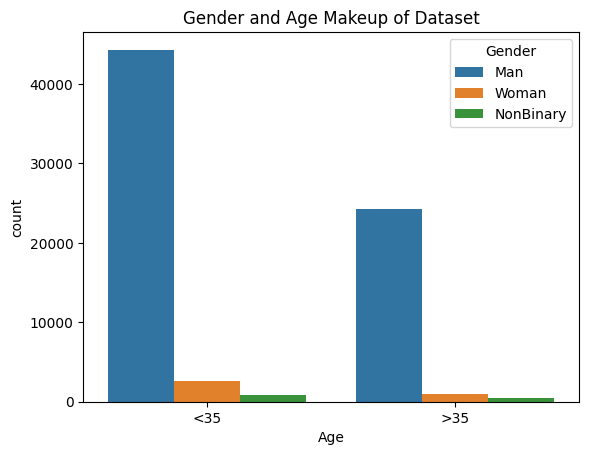

In [ ]:
sns.countplot(data=df, x='Age', hue = 'Gender', order=['<35', '>35'])
plt.title('Gender and Age Makeup of Dataset')

### **Figure #2 Analysis of Most Common Countries Where Responses Come From:**

This plot visualizes the top 20 countries the responses are from. We see that the most frequent countries are U.S.A, India, and Germany and UK. Our analysis is mostly representative of these countries.

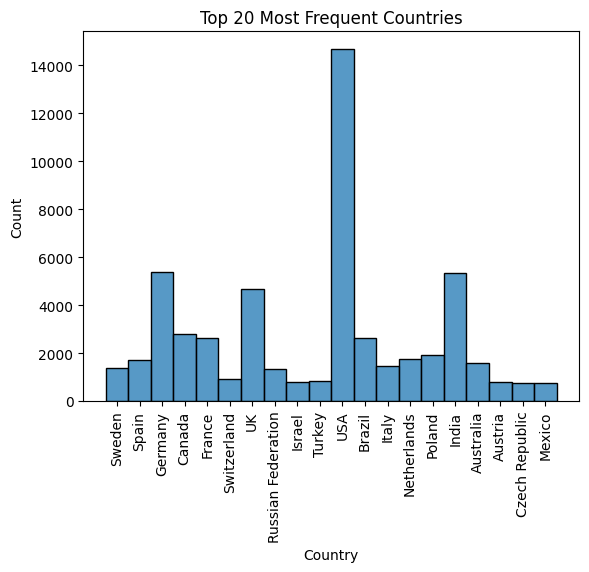

In [ ]:
# Visualizing Most Frequent Responses by Country

# Count the top 20 most frequent countries in the dataset to understand where our data is coming from
countries =  df['Country'].value_counts()
top_20_countries = countries.head(20)
df_top_20 = df[df['Country'].isin(top_20_countries.index)]

# We are replacing the "United Kingdom of Great Britain and Northern Ireland" label with UK so it is easier to query and visualize
# We are replacing United States of America with USA as well
df['Country'] = df['Country'].replace({'United Kingdom of Great Britain and Northern Ireland': 'UK'})
df['Country'] = df['Country'].replace({'United States of America': 'USA'})

# Plot the histogram for the top 20 countries
sns.histplot(data=df_top_20, x='Country')
plt.xticks(rotation=90)
plt.title('Top 20 Most Frequent Countries')
plt.show()

### **Figure #3 Analysis: Education Level By Age**

We are looking at the education levels of the applicants in the dataset by the two age groups.

- **Below 35:** The most frequent degree is an Undergraduate degree followed by Master's degree. We see the least common degree is a PhD. Since this age group is younger it makes sense as to why there are less higher degrees in this dataset and could also signal that some of these applicants may be recent graduates looking for jobs.
- **Above 35:**  Though the breakdown of education level is the same as below 35, we see there is a much lower gap between the amount of individuals with Master's Degree and PhD compared to undergraduate degree only. This can be attributted to the fact that these individuals may have had more time to pursue these degrees given they are older but could also signal that to stay competitive in the job market through generations, people opt for higher degrees.

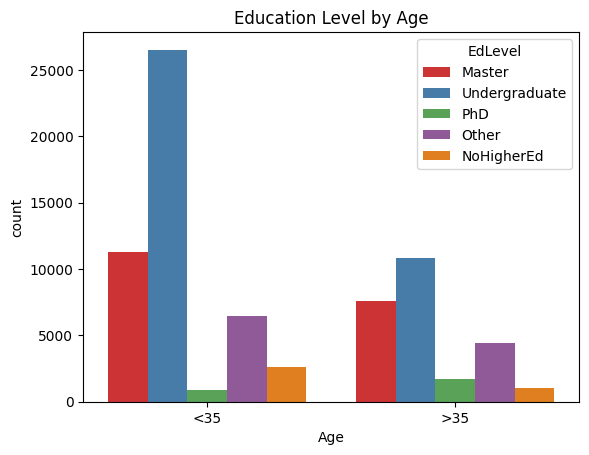

In [ ]:
# We are plotting the Education Levels of our dataset divided by the two age groups
sns.countplot(data= df, x='Age', hue = 'EdLevel', order=['<35', '>35'], palette='Set1')
plt.title('Education Level by Age')
plt.show()

### **Figure #4 Analysis: Years of Coding (Not Professionally) By Age**

We are looking at the years of coding (not professionally) the applicant has and separating it into age groups.

- **Below 35:** We see a significant left skew in the graph indicating most applicants have lower than 15 years of coding experience, with a median of 9 years. This makes sense given the applicant is of lower age but given that these applicants are just below 35 we still see that most of these applicants are not new to coding.
- **Above 35:**  The graph is somewhat normally distributed, with the median being around 22 years. Given that these individuals are older, it makes sense that they would be coding for more years.

Median years of coding experience for age >35: 22.0
Median years of coding experience for age <35: 9.0


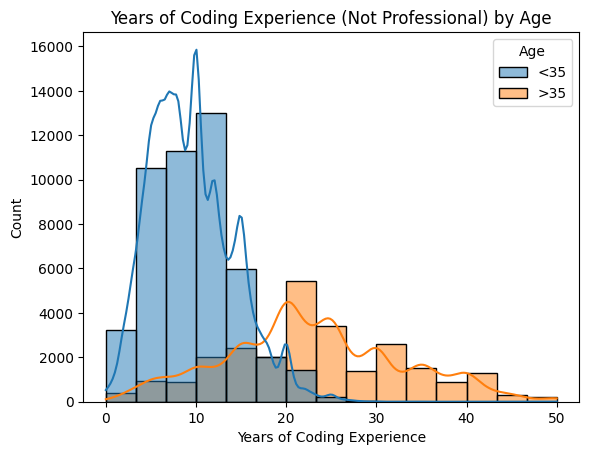

In [ ]:
# Filter the DataFrame for age groups
df_below_35 = df[df['Age'] == '<35']
df_above_35 = df[df['Age'] == '>35']

# Plot the histogram
ax = sns.histplot(data=df, x='YearsCode', bins=15, kde=True, color='blue', hue='Age')

# Calculate and print the median for each group
median_below_35 = df_below_35['YearsCode'].median()
median_above_35 = df_above_35['YearsCode'].median()

print("Median years of coding experience for age >35:", median_above_35)
print("Median years of coding experience for age <35:", median_below_35)

plt.title('Years of Coding Experience (Not Professional) by Age')
ax.set_xlabel('Years of Coding Experience')
plt.show()

### **Figure #5 Analysis: Years Coding Professionally By Age**

We are looking at the professional coding experience of individuals in this dataset broken down by their age group.

- **Below 35:** We see a very significant left skew here with the most common professional experience being 0-2 years. This signals most of these individuals are applying for entry level positions even if they have decades worth of amateur experience coding.
- **Above 35:**  The individuals above 35 have a similar normal distribution but are slightly more left skewed as they have less professional coding experience compared to their coding experience in general.

Median years of professional coding experience for age >35: 15.0
Median years of professional coding experience for age <35: 5.0


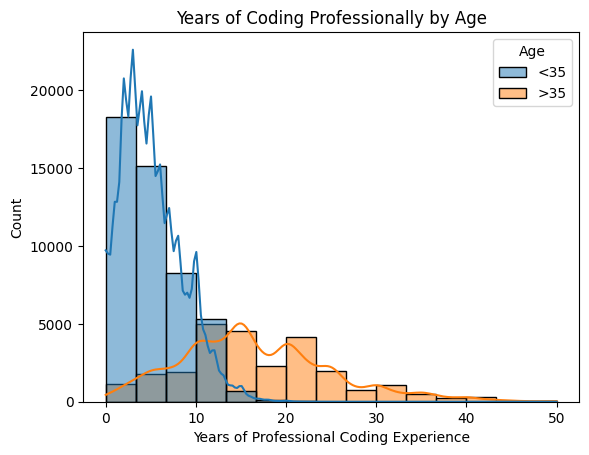

In [ ]:
ax = sns.histplot(data=df, x='YearsCodePro', bins=15, kde=True, color='green', hue = 'Age')
plt.title('Years of Coding Professionally by Age')
ax.set_xlabel('Years of Professional Coding Experience')

median_below_35 = df_below_35['YearsCodePro'].median()
median_above_35 = df_above_35['YearsCodePro'].median()

print("Median years of professional coding experience for age >35:", median_above_35)
print("Median years of professional coding experience for age <35:", median_below_35)

### **Figure #6 Analysis: Number of Coding Skills By Age**

We are looking at the number of coding skills each applicant has and breaking it down by age.

- **Below 35:** There is a left skew of coding skills but this is considering there are outliers with around 100 coding skills listed in the responses. The median coding skill number is 13.
- **Above 35:** The number of computer skills for those above 35 is very similar to those below 35 with the median being 12.

Overall this could signify that coding skills are always relevant.

Median Computer Skills for age >35: 12.0
Median Computer Skills for age <35: 13.0


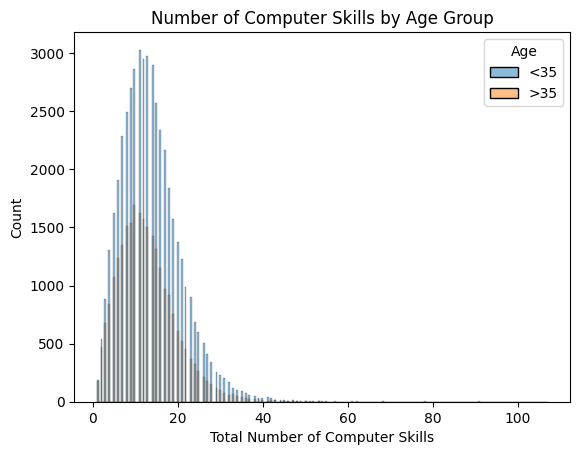

In [ ]:
# Analyzing Number of Skills based on Age
plot = sns.histplot(data=df, x='ComputerSkills', color='blue', hue = 'Age')
plt.title('Number of Computer Skills by Age Group')
plot.set_xlabel('Total Number of Computer Skills')
median_below_35 = df_below_35['ComputerSkills'].median()
median_above_35 = df_above_35['ComputerSkills'].median()

print("Median Computer Skills for age >35:", median_above_35)
print("Median Computer Skills for age <35:", median_below_35)


### **Figure #7 Analysis: Number of Hired Individuals Based on Age**

We are seeing the breakdown of employed individuals based on their age.
- **Below 35:** There are more applicants that have been hired than not hired in this dataset.
- **Above 35:** The number of applicants that are hired is around equal, just slightly more than the number of applicants that haven't been hired. This could signify that it could possibly be slightly more competitive for older applicants to be employed.

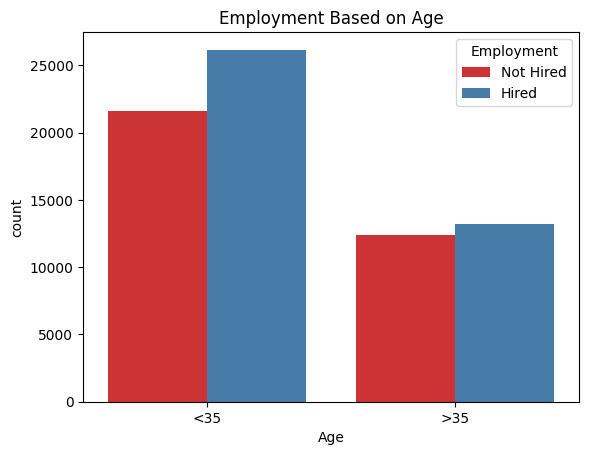

1    39392
0    34007
Name: Employed, dtype: int64


In [ ]:
sns.countplot(data= df, x='Age', hue = 'Employed', palette='Set1', legend=['Not Hired', 'Hired'])
plt.title('Employment Based on Age')
plt.legend(title='Employment', labels=['Not Hired', 'Hired'])
plt.show()
print(df['Employed'].value_counts())

**Important Findings**

From the above EDA on the demographics and makeup of our dataset we notice that there isn't an equal amount of applicants that are in each category of age, gender, education levels, or were employed or not. We see that there are more applicants that are below 35. There are also more applicants that have undergraduate degrees. There are more applicants that have been employed than not hired.

Given this information, when we analyze and visualize the graphs to determine the effect of employability, we are looking at the **proportion of individuals** in a said group that are employed vs not employed to mitigate biases in the visualizations that occur. We will iterate this in the analysis in section 2, for example when analyzing education levels in applicants that were employed we are comparing the proportion of applicants with an undergraduate degree that were hired vs not hired to the proportion of applicants with a master's degree that were hired vs not hired.

# Section 2: Comparing Hired Vs Not Hired Applicants

We are now analyzing our dataset based on whether the individual has been hired or not.

**In the context of the dataframe, if an applicant was employed, it means 1 and unemployed means 0. We represent this as Hired and Not Hired**

We want to see whether the factors we are studying have an effect on employment.


### **Figure #7 Analysis: Analyzing the Education Level of Hired vs Not Hired Applicants**

- **Below 35:** The distribution of education level based on employment is similar. The noteable differences is that a higher amount of undergraduate degree holders were employed rather than not employed. There were more PhD degree holders who were not employed rather than employed.
- **Above 35:** The exact same distribution described for below 35 age group seems to be in the above 35 age group.

This could signify that education level may not have such a significant impact on whether an applicant is selected or not, with higher scrutiny for those that possess high degrees like PhDs and may be applying to more competitive positions. This could also signal that the job market may have more positions for entry level software engineers at the time of this survey.

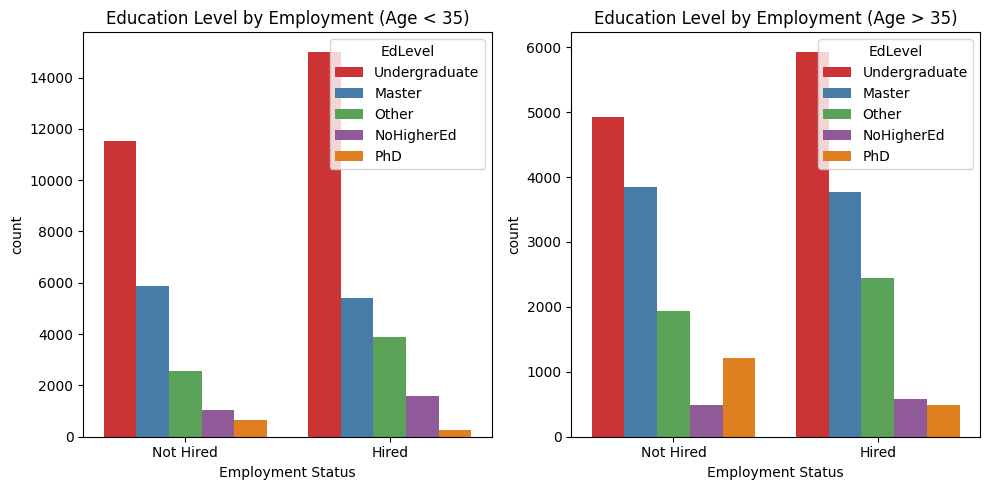

In [ ]:
# Analyze Education Levels Based on Employed vs Not Employed
df_below_35 = df[df['Age'] == '<35']
df_above_35 = df[df['Age'] == '>35']

plt.figure(figsize=(10, 5))
plt1 = plt.subplot(1, 2, 1)
sns.countplot(data=df_below_35, x='Employed', hue='EdLevel', palette='Set1', hue_order=df['EdLevel'].value_counts().index)
plt.title('Education Level by Employment (Age < 35)')
plt1.set_xticks([0, 1])
plt1.set_xlabel('Employment Status')
plt1.set_xticklabels(['Not Hired', 'Hired'])

plt2 = plt.subplot(1, 2, 2)
sns.countplot(data=df_above_35, x='Employed', hue='EdLevel', palette='Set1', hue_order=df['EdLevel'].value_counts().index)
plt.title('Education Level by Employment (Age > 35)')
plt2.set_xticks([0, 1])
plt2.set_xticklabels(['Not Hired', 'Hired'])
plt2.set_xlabel('Employment Status')

plt.tight_layout()
plt.show()

### **Figure #8 Analysis: Analyzing the Years of Coding (Not Professionally) in Hired vs Not Hired Applicants**

The distribution of Hired vs Not Hired individuals seems to be the same based on their personal years of coding. However, we can note that a higher proportion of unselected applicants have 0-2 years of coding experience when compared to hired applicants.

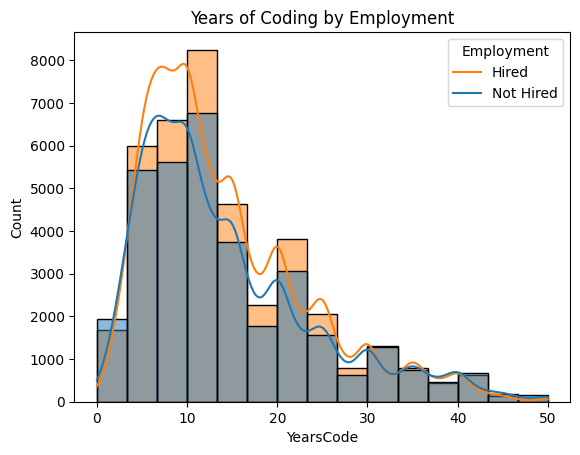

In [ ]:
sns.histplot(data=df, x='YearsCode', bins=15, kde=True, color='blue', hue = 'Employed')
plt.title('Years of Coding by Employment')
plt.legend(title='Employment', labels=['Hired', 'Not Hired'])

### **Figure #9 Analysis: Analyzing the Years of Professional Coding Experience in Hired vs Unhired Applicants**

The distribution of Hired vs Unhired individuals seems to be the same based on their professional years of coding.

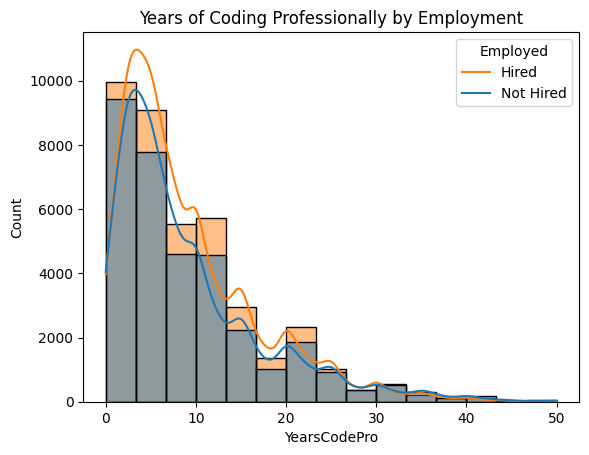

In [ ]:
# Analyze Years Coding Professionally Based on Employed vs Not Employed
sns.histplot(data=df, x='YearsCodePro', bins=15, kde=True, color='blue', hue = 'Employed')
plt.title('Years of Coding Professionally by Employment')
plt.legend(title='Employed', labels=['Hired', 'Not Hired'])

## **Figure #10 Analysis: Analyzing the Number of Computer Skills For Hired vs Unhired Applicants Broken Down By Age Group**

Based on this initial visualization we immediately see that for both age groups applicants that were not hired had lower number of total skills compared to applicants who were hired.

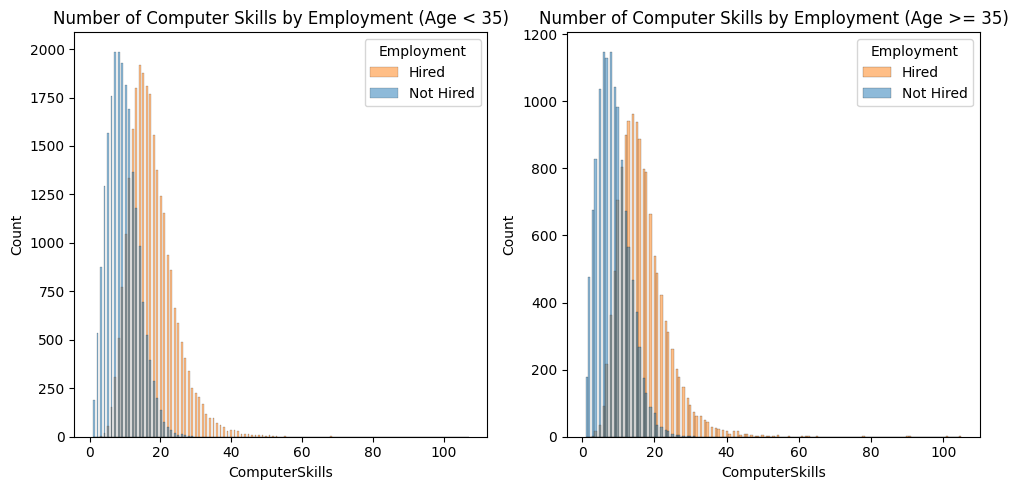

In [4]:
# Analyze Number of Coding Skills Based on Employed vs Not Employed
# Analyzing Number of Skills based on Age
df_below_35 = df[df['Age'] == '<35']
df_above_35 = df[df['Age'] == '>35']
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df_below_35, x='ComputerSkills', hue='Employed')
plt.title('Number of Computer Skills by Employment (Age < 35)')
plt.legend(title='Employment', labels=['Hired', 'Not Hired'])

plt.subplot(1, 2, 2)
sns.histplot(data=df_above_35, x='ComputerSkills', hue='Employed')
plt.title('Number of Computer Skills by Employment (Age >= 35)')
plt.legend(title='Employment', labels=['Hired', 'Not Hired'])

plt.tight_layout()
plt.show()

## **Statistical Analysis of Computer Skills in Hired vs Not Hired Applicants:**

We see that the average number of computer skills for unselected applicants is 9 while it is 17 for the employed applicants.

In [ ]:
# Describe the number of computer skills for employed and unemployed individuals
employed_df = df[df['Employed'] == 1]
unemployed_df = df[df['Employed'] == 0]
print("Employed\n",employed_df['ComputerSkills'].describe())
print("Unemployed\n", unemployed_df['ComputerSkills'].describe())

Employed
 count    39392.000000
mean        17.271578
std          6.699134
min          3.000000
25%         13.000000
50%         16.000000
75%         21.000000
max        107.000000
Name: ComputerSkills, dtype: float64
Unemployed
 count    34007.000000
mean         9.001147
std          4.310253
min          1.000000
25%          6.000000
50%          9.000000
75%         12.000000
max         34.000000
Name: ComputerSkills, dtype: float64




> We see that there is a significant difference between the number of computer skills employed vs unemployed applicants had, almost double the amount. We want to analyze below if there are any particular skills that selected applicants had versus the skills unselected applicants had.



> Here we are listing the top 15 most frequent skills for applicants that were employed

In [ ]:
from collections import Counter

# We now want to see the most frequent skills that employed individuals have
employed_df = df[df['Employed'] == 1]

skills_list = employed_df['HaveWorkedWith'].explode().dropna()

employed_skill_counts = Counter(skills_list)

most_frequent_skills = employed_skill_counts.most_common(15)

print("Top 15 Most Frequent Skills among Employed Individuals:")
for skill, count in most_frequent_skills:
    print(f"{skill}: {count}")

Top 15 Most Frequent Skills among Employed Individuals:
JavaScript: 33720
HTML/CSS: 27931
SQL: 25467
Docker: 24453
TypeScript: 23080
Node.js: 22606
MySQL: 19032
AWS: 18843
Git: 18496
PostgreSQL: 18142
React.js: 17783
C#: 17267
Python: 16708
Microsoft SQL Server: 16331
Java: 16020


> Here we are listing the top 15 most frequent skills for applicants that were not employed

In [ ]:
unemployed_df = df[df['Employed'] == 0]

skills_list = unemployed_df['HaveWorkedWith'].explode().dropna()

unemployed_skill_counts = Counter(skills_list)

most_frequent_skills = unemployed_skill_counts.most_common(15)

print("Top 15 Most Frequent Skills among Unemployed Individuals:")
for skill, count in most_frequent_skills:
    print(f"{skill}: {count}")

Top 15 Most Frequent Skills among Unemployed Individuals:
Git: 17415
Docker: 15771
JavaScript: 15627
Python: 14451
SQL: 12894
AWS: 12747
HTML/CSS: 12276
PostgreSQL: 11960
MySQL: 10458
React.js: 6912
Bash/Shell: 6728
Java: 6633
C++: 5577
Redis: 5574
Kubernetes: 5457


## **Figure #11: Analyzing The Most Frequent Skills Among Hired vs Not Hired Applicants**

Here we see that the skills remain mostly the same between employed and not employed applicants with the exception of TypeScript and Node.js which are only found in the visualization for employed applicants and React.js and Python which is only found in the unemployed applicants. However the order of these skills vary between the employed vs unemployed applicants signaling that some of these skills could be more useful than others to list on your application.


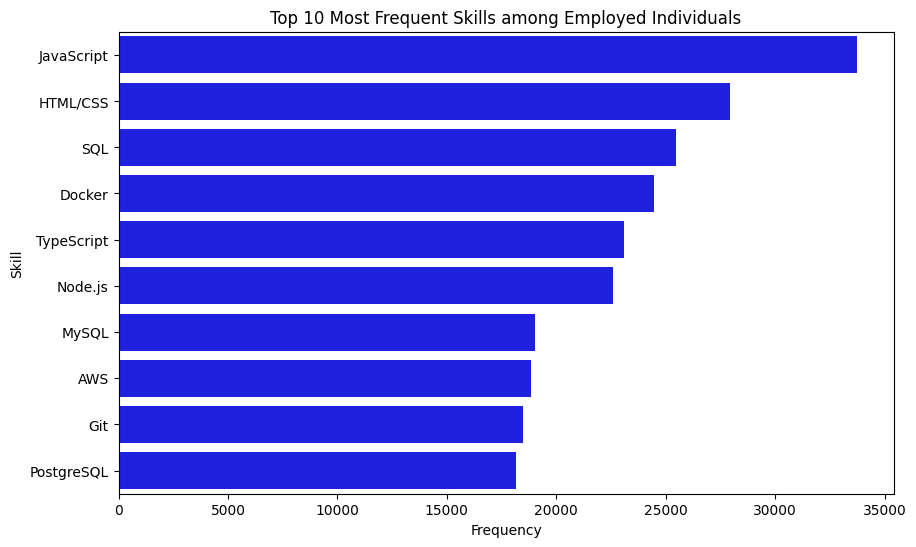

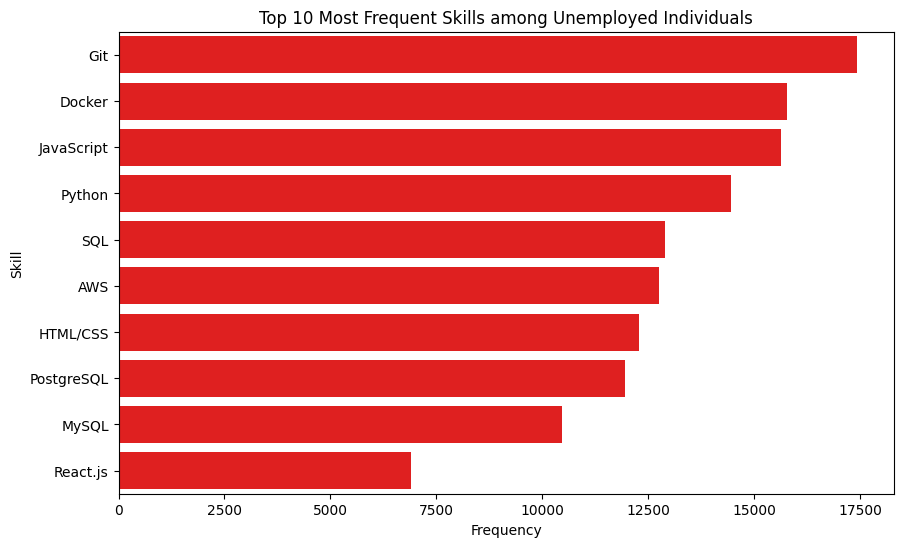

In [ ]:

# Count the occurrences of each skill for each group

top_10_employed_skills = employed_skill_counts.most_common(10)
top_10_unemployed_skills = unemployed_skill_counts.most_common(10)

# Plot the most frequent skills for employed individuals
plt.figure(figsize=(10, 6))
sns.barplot(x=[count for skill, count in top_10_employed_skills], y=[skill for skill, count in top_10_employed_skills], color='blue')
plt.xlabel('Frequency')
plt.ylabel('Skill')
plt.title('Top 10 Most Frequent Skills Among Employed Individuals')
plt.show()

# Plot the most frequent skills for unemployed individuals
plt.figure(figsize=(10, 6))
sns.barplot(x=[count for skill, count in top_10_unemployed_skills], y=[skill for skill, count in top_10_unemployed_skills], color='red')
plt.xlabel('Frequency')
plt.ylabel('Skill')
plt.title('Top 10 Most Frequent Skills Among Unemployed Individuals')
plt.show()

# Ethics & Privacy

In considering the ethics and privacy implications of our data science project, we acknowledge the importance of addressing potential biases and privacy concerns. One key issue is the possibility of biases in the dataset, such as underrepresentation of certain demographics or industries. This could lead to skewed analysis results and hinder the equitable assessment of educational requirements across different sectors. Additionally, there are privacy concerns related to the collection and sharing of personal information, including educational background, income, and employment history. It's essential to ensure compliance with data privacy regulations and respect individuals' rights to privacy throughout the project.

To detect and mitigate biases, we plan to conduct thorough reviews of the dataset before analysis, looking for any demographic or selection biases in data collection. During analysis, we will employ techniques such as stratification or subgroup analysis to identify and address biases that may impact the results. When communicating the analysis findings, we will be transparent about any limitations or biases in the dataset and methodology used, providing context to the audience and enabling them to interpret the results accurately. After analyzing our dataset we see that there is potential bias as the number of women and non-binary individuals in the dataset is very low compared to men. Furthermore, our data mostly comes from the USA, India, and other English Speaking countries. Along with that there is a lower proportion of individuals of age higher than 35. Considering all of this we must transparently form a conclusion knowing that our dataset does not represent all genders, ages, and countries equally.

To handle these issues, we will explore strategies such as data anonymization, aggregation, or obtaining consent from participants to address privacy concerns. We will also collaborate with experts in ethics, privacy, and data governance to ensure compliance with ethical standards and regulations throughout the project. By proactively addressing ethics and privacy concerns, we aim to conduct our analysis ethically, respect individuals' privacy rights, and produce equitable and reliable results.

# Discussion and Conclusion

###Conclusion
At the conclusion of our research, we were able to prove our original hypothesis is which the higher the number of skills an applicant has, the more likely they will be hired in the software engineering field. However, we were unable to support the importance of the education level and coding experience in the process of being considered and then employed.

When starting this project, we all came in with our own notions and prior knowledge of what it will take to become an active part of the workforce. These notions only continued to be supported with our background research as candidates with formal education credential and with a college degree are prioritized over those without. However, the conflict of opinion begins outside of education and where our research project begins. There is continuous different information on what a job requires and even more conflicting information on the  recommendations, such as the abilities and experience it takes to secure the job position. Based on the background research, we established there are additional skill sets and unsaid wickets that must be hit in order to increase chances of employability. Through this project, we have uncovered some of these uncertain wickets through actual job applications and detailing out what is necessary to be a competitive job candidate.

Considering the results of the exploratory data analysis, we noticed that the factor which had the most significant impact on employment was the number of computer skills. We noticed that the average number of computer skills for applicants who were not hired is 9 while it is 17 for the hired applicants. Considering this significant difference we can conclude that having a wide range of computer skills is a very important factor in determining employability. Furthermore, this trend is evident in both the below 35 age group and above 35 age group, emphasizing that skillset is important in all stages of a career. In terms of impact of education level on employment, we could not see a significant correlation between education level and whether an applicant was hired as the distribution of education levels was similar across both employed and unemployed applicants. However, we saw that a higher proportion of individuals with undergraduate degrees were hired rather than not hired while we saw that slightly smaller proportion of applicants with Master's and PhD degrees were hired compared to those that were not hired. In terms of years of professional experience coding, we were surprised to see a very similar distribution again in terms of hired vs not hired applicants based on the years they have been coding professionally. However, we saw that a higher number of individuals that have 0-2 years of coding experience professionally were not hired.

###Limitations

In this research project, we had run into a few limitations to our project. The first limitation is the dataset, due to time and our research question. There were many times in which we had to switch the research question as we were unable to find a dataset that would be able to answer the question. Additionally, with the dataset, since we were only able to acquire one, we are heavily limited in our generalization of our findings. The dataset would only be applying to those in the software engineering field and can not be compared to other occupational field.

###Application

Despite these limitations, the information still stands pertinenet. The software enginneering is a growing field and a lot of the requirements necessary to apply and be employed into technology based jobs will still apply. The current goal when starting the project was to understand what was necessary to be able to appy to these jobs, and this lays the foundations of what we should be working towards before we graduate. As we are still students, we can work towards building more much skills and in the time being and focus on learning what we can, rather than focusing on looking for jobs.





# Team Contributions



- Nathan Huey: Background and Prior Work, Data Wrangling
- Albert Nguyen: Coordinating Meetings and Communication, Ethics and Privacy, Search for Data Sets, Timeline.
- Sriya Paleti: Data Description/Acquisition, EDA Analysis Section 1 & 2, Research Question, Hypothesis, Conclusion, Video(Slides)
- Sara Tsai: Abstract, Conclusion, Limitations, Coordinating Meetings and Communication, Video
- Ellen Wrightsman